### Multiple Linear Regression with `Carseats` Dataset

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data

Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [11]:
Carseats

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


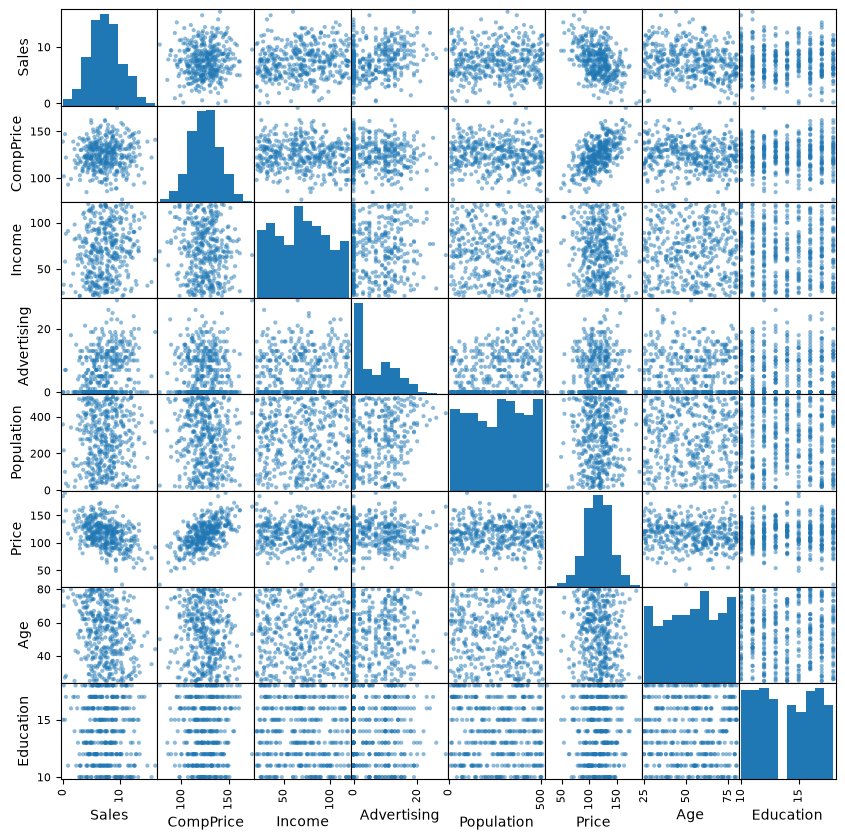

In [12]:
pd.plotting.scatter_matrix(Carseats, figsize=(10,10));

#### (a) Fit a Multiple Regression Model with to predict `Sales` with `Price`, `Urban` and `US`

- Price is quantitative
- Urban and US are both qualitative variables so I will need to one-hot encode them

Some notes
- F-statistic probability looks good, shows that there is a relationship between at least one variable.
- t-statistic probabilities for each variable looks good except for `Urban`. Perhaps `Urban` does not have a relationship with `Sales` in the presence of `Price` and `US`.

In [17]:
y = Carseats[['Sales']]
X = pd.DataFrame({
    'Intercept': np.ones(Carseats.shape[0]),
    'Price': Carseats['Price'],
    'Urban': Carseats['Urban'],
    'US': Carseats['US'],
})
X = pd.get_dummies(X, columns=['Urban', 'US'], drop_first=True, dtype=int)

In [18]:
results = sm.OLS(y, X).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Thu, 16 Jul 2026   Prob (F-statistic):           2.39e-23
Time:                        15:44:56   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0435      0.651     20.036      0.000      11.764      14.323
Price         -0.0545      0.005    -10.389      0.000      -0.065      -0.044
Urban_Yes     -0.0219      0.272     -0.081      0.936      -0.556       0.512
US_Yes         1.2006      0.259      4.635      0.000       0.691       1.710
==============================================================================
Omnibus:                        0.676   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.713   Jarque-Bera (JB):                0.758
Skew:                           0.093   Prob(JB):                        0.684
Kurtosis:                       2.897   Cond. No.                         628.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### (b) Provide an interpretation of each coefficient in the model

Coefficients:
- Intercept: Value of `Sales` when all variables `Price`, `Urban`, `US` are zero.
- `Price`: Increase in `Sales` for each unit of `Price`
- `Urban`: Increase in `Sales` when the store is in an Urban location
- `US`: Increase in `Sales` when the store is in the US

#### (c) Model in equation form

$\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1x_1 + \hat{\beta}_2x_2 + \hat{\beta}_3x_3$

Where

$x_1$ is the Price

$x_2$ is 1 if the store is in an Urban location, 0 otherwise

$x_3$ is 1 if the store is in the US, 0 otherwise

#### (d) Predicts that we can reject the null hypothesis.

1. In the absence of `Price`, `Urban`, and `US`, we can reject the null hypothesis that the intercept is 0.
2. In the presence of `Urban` and `US`, we can reject the null hypothesis that `Price` has no relationship with `Sales`.
3. In the presence of `Price` and `Urban`, we can reject the null hypothesis that `US` has no relationship with `Sales`.

#### (e) Fit smaller model with only predictors that we rejected the null hypothesis for

Notes
- I removed `Urban` from the last model
- It seems that R^2 did not change, and the coefficients for the other variables did not change much.

In [20]:
X_small = pd.DataFrame({
    'Intercept': np.ones(Carseats.shape[0]),
    'Price': Carseats['Price'],
    'US': Carseats['US']
})
X_small = pd.get_dummies(X_small, columns=['US'], drop_first=True, dtype=int)
X_small[:4]

,Intercept,Price,US_Yes
0,1.0,120,1
1,1.0,83,1
2,1.0,80,1
3,1.0,97,1


In [21]:
results_small = sm.OLS(y, X_small).fit()
results_small.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Thu, 16 Jul 2026   Prob (F-statistic):           2.66e-24
Time:                        15:54:25   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     13.0308      0.631     20.652      0.000      11.790      14.271
Price         -0.0545      0.005    -10.416      0.000      -0.065      -0.044
US_Yes         1.1996      0.258      4.641      0.000       0.692       1.708
==============================================================================
Omnibus:                        0.666   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.717   Jarque-Bera (JB):                0.749
Skew:                           0.092   Prob(JB):                        0.688
Kurtosis:                       2.895   Cond. No.                         607.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### (f) How well do the models in (a) and (e) fit the data?

- R^2 value is 0.239 for both models, showing that they explain 0.239 of the variance in the model.
- RSE value is about 6.09 for (e) and 6.11 for (a). This is quite a large proportion of the mean of the fitted values. This shows that the model does not do very much for explaining the relationship and is not much better than a random guess.
- Residual plots show no discernible pattern. We can conclude that based on `Price` and `US` variables, the data is somewhat linear and can be modelled by a linear model.


In [34]:
print(f"RSE for (a) is {results.scale}, this is {results.scale / np.mean(results.fittedvalues)} of the mean of fitted values")
print(f"RSE for (e) is {results_small.scale}, this is {results_small.scale / np.mean(results_small.fittedvalues)} of the mean of fitted values")

RSE for (a) is 6.113218867193113, this is 0.8154954417255269 of the mean of fitted values
RSE for (e) is 6.097920558687301, this is 0.8134546672786056 of the mean of fitted values


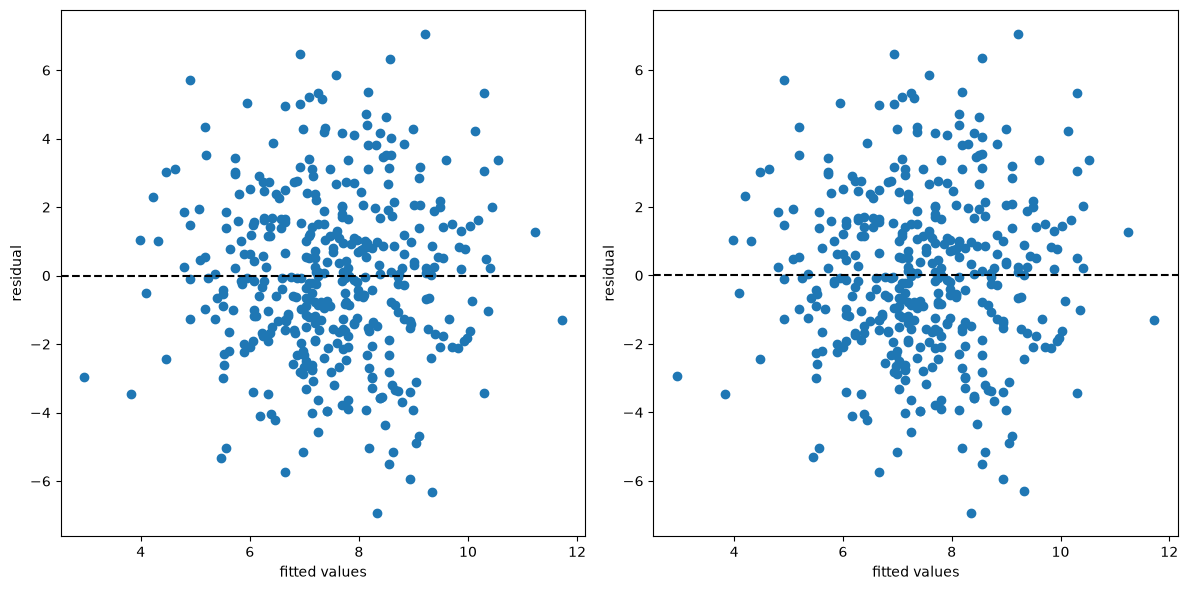

In [30]:
fig, axs = plt.subplots(ncols=2, figsize=(12,6))
axs[0].scatter(x=results.fittedvalues, y=results.resid)
axs[0].set_xlabel("fitted values")
axs[0].set_ylabel("residual")
axs[0].axhline(y=0, c='k', ls='--')

axs[1].scatter(x=results_small.fittedvalues, y=results_small.resid)
axs[1].set_xlabel("fitted values")
axs[1].set_ylabel("residual")
axs[1].axhline(y=0, c='k', ls='--')

plt.tight_layout()

#### (g) 95% confidence intervals for model in (e)
- Intercept: [11.790, 14.271]
- Price: [-0.065, -0.044]
- US: [0.692, 1.708]

#### (h) Outlier and Leverage Analysis for model in (e)
- We will plot a studentized residual plot for outlier analysis, and a leverage plot for leverage analysis
- Outlier analysis: All points are within 3 standard errors so there are no outliers
- Leverage: One point near 50 has higher leverage than the rest, but since there are no outliers this should be fine.

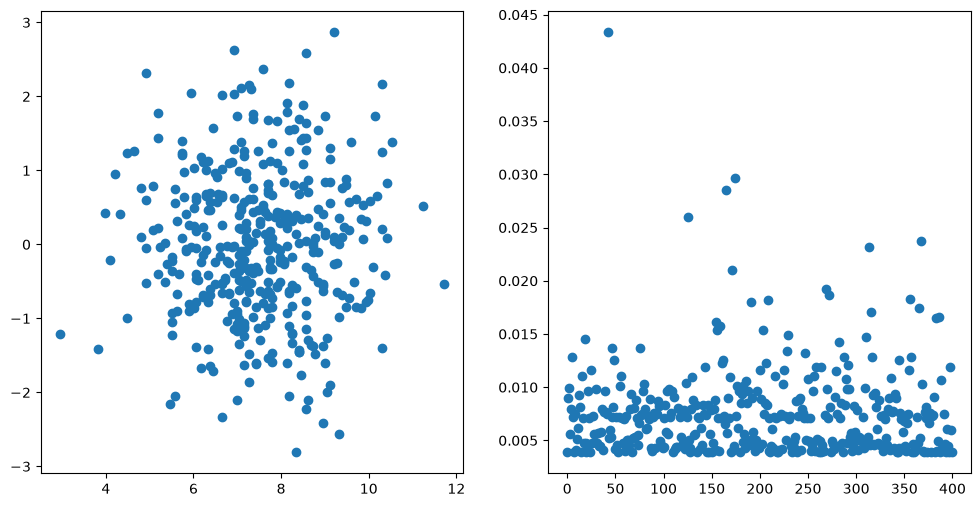

In [38]:
fig, axs = plt.subplots(ncols=2, figsize=(12,6))
axs[0].scatter(x=results_small.fittedvalues, y=results_small.get_influence().resid_studentized_internal)
axs[1].scatter(x=X_small.index, y=results_small.get_influence().hat_matrix_diag)